In [1]:
# CELL 1: SETUP & IMPORTS
import os
import time
import json
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Buat folder untuk menyimpan semua hasil agar tidak berantakan
SAVE_DIR = "results_exp4"
os.makedirs(SAVE_DIR, exist_ok=True)

# Cek ketersediaan GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan device: {device}")
if torch.cuda.is_available():
    print(f"Nama GPU: {torch.cuda.get_device_name(0)}")

Menggunakan device: cuda
Nama GPU: NVIDIA GeForce RTX 5070


In [2]:
# CELL 2: FOCAL LOSS
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce_loss(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [3]:
# CELL 3: DATASET & STRATIFIED K-FOLD (UPDATED LOCAL PATHS)
import os
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import StratifiedKFold

# 1. Kunci Lokasi Data Lokal
data_dir = r"C:\Users\asfan\Data\ham10000\full"
csv_path = r"C:\Users\asfan\Data\ham10000\HAM10000_metadata.csv"

# 2. Baca Metadata dan Petakan Kelas
df = pd.read_csv(csv_path)
class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
class_to_idx = {c: i for i, c in enumerate(class_names)}

# Mapping kelas teks ('dx') menjadi indeks angka
df['label'] = df['dx'].map(class_to_idx)

# Membangun full path untuk setiap gambar secara otomatis
# Asumsi format gambar adalah .jpg dan nama file sama dengan image_id
df['image_path'] = df.apply(lambda row: os.path.join(data_dir, row['dx'], f"{row['image_id']}.jpg"), axis=1)

# Verifikasi path (Cek apakah gambar pertama benar-benar ada)
print(f"Total data: {len(df)}")
print(f"Contoh path gambar: {df.iloc[0]['image_path']}")
if not os.path.exists(df.iloc[0]['image_path']):
    print("WARNING: Path gambar tidak ditemukan! Pastikan ekstensi .jpg atau nama folder sesuai.")

# 3. Class Dataset Kustom
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['image_path']
        label = self.dataframe.iloc[idx]['label']
        
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# 4. Augmentasi Data
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 5. Persiapan Stratified 5-Fold
X = df['image_path'].values
y = df['label'].values
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Dataset dan Stratified K-Fold siap!")

Total data: 10015
Contoh path gambar: C:\Users\asfan\Data\ham10000\full\bkl\ISIC_0027419.jpg
Dataset dan Stratified K-Fold siap!


In [4]:
# CELL 4 (REVISI UNTUK EXP 4): ConvNeXt + Coordinate Attention
class CoordAtt(nn.Module):
    def __init__(self, inp, oup, reduction=32):
        super(CoordAtt, self).__init__()
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))

        mip = max(8, inp // reduction)

        self.conv1 = nn.Conv2d(inp, mip, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(mip)
        self.act = nn.Hardswish()
        
        self.conv_h = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        self.conv_w = nn.Conv2d(mip, oup, kernel_size=1, stride=1, padding=0)
        
    def forward(self, x):
        identity = x
        
        n, c, h, w = x.size()
        x_h = self.pool_h(x)
        x_w = self.pool_w(x).permute(0, 1, 3, 2)

        y = torch.cat([x_h, x_w], dim=2)
        y = self.conv1(y)
        y = self.bn1(y)
        y = self.act(y) 
        
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)

        a_h = self.conv_h(x_h).sigmoid()
        a_w = self.conv_w(x_w).sigmoid()

        out = identity * a_h * a_w
        return out

class ConvNeXt_CA_Attention(nn.Module):
    def __init__(self, num_classes=7):
        super(ConvNeXt_CA_Attention, self).__init__()
        convnext = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)
        self.features = convnext.features
        
        # Injeksi Coordinate Attention
        self.ca = CoordAtt(768, 768)
        
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(1),
            nn.LayerNorm(768, eps=1e-6),
            nn.Linear(768, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.ca(x) # Coordinate Attention
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

In [5]:
# CELL 5: TRAINING ENGINE WITH METRIC TRACKING & EPOCH TIMER
def train_model(fold, model, train_loader, val_loader, criterion, optimizer, num_epochs=50):
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    start_time_total = time.time()
    torch.cuda.reset_peak_memory_stats()
    
    for epoch in range(num_epochs):
        epoch_start_time = time.time() # Mulai hitung waktu per epoch
        
        # --- TRAINING PHASE ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data)
            total += labels.size(0)
            
        epoch_train_loss = running_loss / total
        epoch_train_acc = correct.double() / total
        
        # --- VALIDATION PHASE ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels.data)
                val_total += labels.size(0)
                
        epoch_val_loss = val_loss / val_total
        epoch_val_acc = val_correct.double() / val_total
        
        # Hitung durasi epoch
        epoch_end_time = time.time()
        duration = epoch_end_time - epoch_start_time
        minutes = int(duration // 60)
        seconds = int(duration % 60)
        
        # Simpan metrik ke history
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc.item())
        history['val_acc'].append(epoch_val_acc.item())
        
        # Output sesuai permintaan (ditambah durasi)
        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f} - {minutes} menit {seconds} detik")
        
        # Simpan model terbaik (.pth) - Update ke exp3
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            model_save_path = os.path.join(SAVE_DIR, f"exp4_fold{fold}_best_model.pth")
            torch.save(model.state_dict(), model_save_path)
            
    # Kalkulasi performa total
    end_time_total = time.time()
    training_time_total = end_time_total - start_time_total
    max_memory = torch.cuda.max_memory_allocated() / (1024 ** 2) 
    
    # Simpan history ke JSON
    with open(os.path.join(SAVE_DIR, f"exp4_fold{fold}_history.json"), 'w') as f:
        json.dump(history, f)
        
    return history, training_time_total, max_memory

In [6]:
# CELL 6: EVALUATION & REPORTING
def evaluate_and_plot(fold, model, val_loader, history, training_time, max_memory, class_names):
    # Load model terbaik
    model.load_state_dict(torch.load(os.path.join(SAVE_DIR, f"exp4_fold{fold}_best_model.pth")))
    model.eval()
    
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # 1. Classification Report & Metrics
    report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(SAVE_DIR, f"exp4_fold{fold}_classification_report.csv"))
    
    # Simpan resource metrik
    resource_log = {
        'training_time_seconds': training_time,
        'max_gpu_memory_mb': max_memory,
        'overall_accuracy': accuracy_score(all_labels, all_preds)
    }
    with open(os.path.join(SAVE_DIR, f"exp4_fold{fold}_resources.json"), 'w') as f:
        json.dump(resource_log, f)
        
    # 2. Plot Loss & Accuracy Curves
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history['train_loss'], label='Train Loss')
    ax1.plot(history['val_loss'], label='Val Loss')
    ax1.set_title(f'Loss Curve - Fold {fold}')
    ax1.legend()
    
    ax2.plot(history['train_acc'], label='Train Acc')
    ax2.plot(history['val_acc'], label='Val Acc')
    ax2.set_title(f'Accuracy Curve - Fold {fold}')
    ax2.legend()
    plt.savefig(os.path.join(SAVE_DIR, f"exp4_fold{fold}_learning_curves.png"))
    plt.show()
    
    # 3. Plot Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.savefig(os.path.join(SAVE_DIR, f"exp4_fold{fold}_confusion_matrix.png"))
    plt.show()
    
    print(f"Semua log dan grafik untuk Fold {fold} berhasil disimpan di folder: {SAVE_DIR}")

# CONTOH EKSEKUSI (Bisa diletakkan di dalam loop Stratified K-Fold)
# class_names = ['AKIEC', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'VASC']
# criterion = FocalLoss(gamma=2)
# optimizer = optim.Adam(model.parameters(), lr=1e-4)
# history, t_time, max_mem = train_model(fold=1, model=model, train_loader=train_loader, val_loader=val_loader, criterion=criterion, optimizer=optimizer)
# evaluate_and_plot(fold=1, model=model, val_loader=val_loader, history=history, training_time=t_time, max_memory=max_mem, class_names=class_names)

Mulai Eksperimen 4: ConvNeXt + CBAM + Focal Loss
Menyimpan di folder: results_exp4

---> Memulai Fold 1 <---
Epoch 1/50 - Train Loss: 0.4096 Acc: 0.7431 | Val Loss: 0.2428 Acc: 0.8083 - 2 menit 8 detik
Epoch 2/50 - Train Loss: 0.2153 Acc: 0.8364 | Val Loss: 0.2189 Acc: 0.8218 - 2 menit 10 detik
Epoch 3/50 - Train Loss: 0.1478 Acc: 0.8773 | Val Loss: 0.1588 Acc: 0.8762 - 2 menit 11 detik
Epoch 4/50 - Train Loss: 0.1102 Acc: 0.8995 | Val Loss: 0.1514 Acc: 0.8687 - 2 menit 16 detik
Epoch 5/50 - Train Loss: 0.0790 Acc: 0.9249 | Val Loss: 0.1398 Acc: 0.8822 - 2 menit 11 detik
Epoch 6/50 - Train Loss: 0.0608 Acc: 0.9400 | Val Loss: 0.1413 Acc: 0.8867 - 2 menit 10 detik
Epoch 7/50 - Train Loss: 0.0459 Acc: 0.9481 | Val Loss: 0.1280 Acc: 0.9001 - 2 menit 10 detik
Epoch 8/50 - Train Loss: 0.0417 Acc: 0.9577 | Val Loss: 0.1250 Acc: 0.8942 - 2 menit 10 detik
Epoch 9/50 - Train Loss: 0.0342 Acc: 0.9664 | Val Loss: 0.1706 Acc: 0.8862 - 2 menit 10 detik
Epoch 10/50 - Train Loss: 0.0239 Acc: 0.9712 |

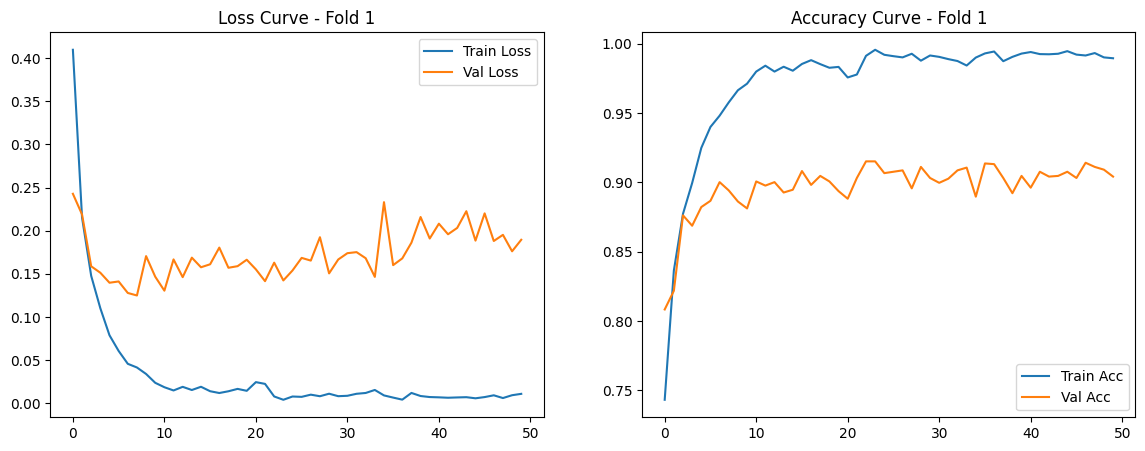

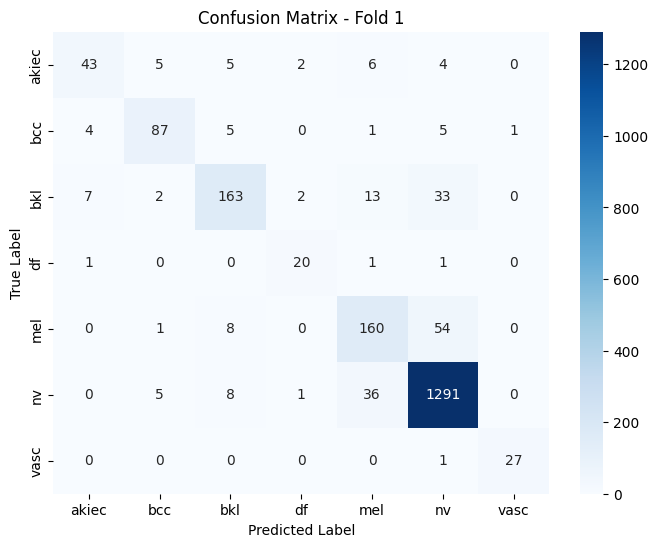

Semua log dan grafik untuk Fold 1 berhasil disimpan di folder: results_exp4

---> Memulai Fold 2 <---
Epoch 1/50 - Train Loss: 0.3947 Acc: 0.7507 | Val Loss: 0.2560 Acc: 0.8258 - 2 menit 13 detik
Epoch 2/50 - Train Loss: 0.2247 Acc: 0.8225 | Val Loss: 0.2053 Acc: 0.8372 - 2 menit 9 detik
Epoch 3/50 - Train Loss: 0.1470 Acc: 0.8739 | Val Loss: 0.2102 Acc: 0.8432 - 2 menit 9 detik
Epoch 4/50 - Train Loss: 0.1082 Acc: 0.9036 | Val Loss: 0.1684 Acc: 0.8757 - 2 menit 11 detik
Epoch 5/50 - Train Loss: 0.0912 Acc: 0.9144 | Val Loss: 0.1549 Acc: 0.8847 - 2 menit 10 detik
Epoch 6/50 - Train Loss: 0.0709 Acc: 0.9274 | Val Loss: 0.1622 Acc: 0.8787 - 2 menit 10 detik
Epoch 7/50 - Train Loss: 0.0486 Acc: 0.9513 | Val Loss: 0.1361 Acc: 0.9001 - 2 menit 11 detik
Epoch 8/50 - Train Loss: 0.0384 Acc: 0.9608 | Val Loss: 0.1245 Acc: 0.9091 - 2 menit 10 detik
Epoch 9/50 - Train Loss: 0.0325 Acc: 0.9649 | Val Loss: 0.1408 Acc: 0.9041 - 2 menit 10 detik
Epoch 10/50 - Train Loss: 0.0354 Acc: 0.9626 | Val Los

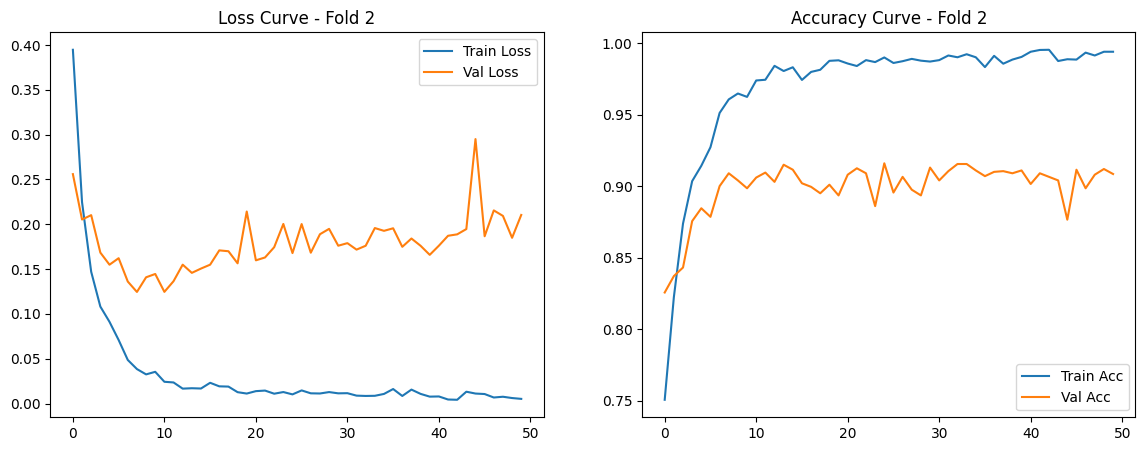

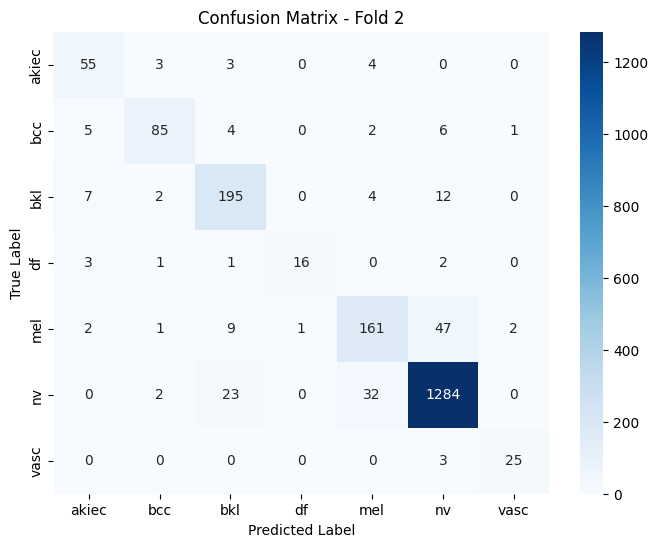

Semua log dan grafik untuk Fold 2 berhasil disimpan di folder: results_exp4

---> Memulai Fold 3 <---
Epoch 1/50 - Train Loss: 0.3811 Acc: 0.7590 | Val Loss: 0.2555 Acc: 0.8163 - 2 menit 8 detik
Epoch 2/50 - Train Loss: 0.1960 Acc: 0.8497 | Val Loss: 0.1939 Acc: 0.8552 - 2 menit 9 detik
Epoch 3/50 - Train Loss: 0.1410 Acc: 0.8779 | Val Loss: 0.1617 Acc: 0.8627 - 2 menit 9 detik
Epoch 4/50 - Train Loss: 0.0979 Acc: 0.9060 | Val Loss: 0.1618 Acc: 0.8602 - 2 menit 9 detik
Epoch 5/50 - Train Loss: 0.0789 Acc: 0.9197 | Val Loss: 0.1504 Acc: 0.8837 - 2 menit 9 detik
Epoch 6/50 - Train Loss: 0.0625 Acc: 0.9330 | Val Loss: 0.2302 Acc: 0.8557 - 2 menit 9 detik
Epoch 7/50 - Train Loss: 0.0511 Acc: 0.9453 | Val Loss: 0.1625 Acc: 0.8842 - 2 menit 9 detik
Epoch 8/50 - Train Loss: 0.0375 Acc: 0.9597 | Val Loss: 0.1751 Acc: 0.8882 - 2 menit 9 detik
Epoch 9/50 - Train Loss: 0.0268 Acc: 0.9702 | Val Loss: 0.1770 Acc: 0.8807 - 2 menit 9 detik
Epoch 10/50 - Train Loss: 0.0218 Acc: 0.9755 | Val Loss: 0.15

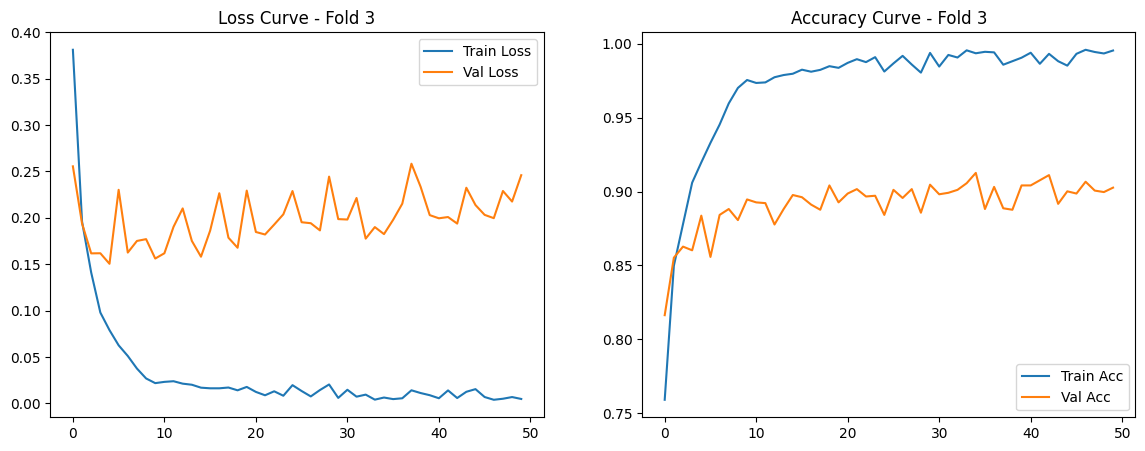

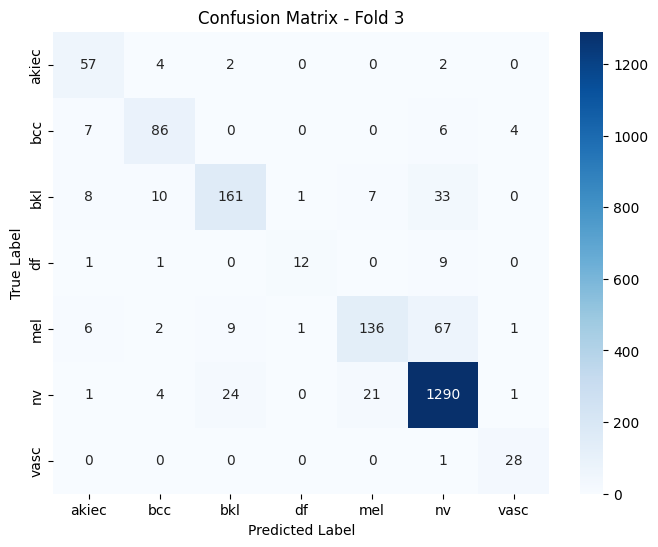

Semua log dan grafik untuk Fold 3 berhasil disimpan di folder: results_exp4

---> Memulai Fold 4 <---
Epoch 1/50 - Train Loss: 0.3962 Acc: 0.7480 | Val Loss: 0.2502 Acc: 0.8168 - 2 menit 9 detik
Epoch 2/50 - Train Loss: 0.2038 Acc: 0.8402 | Val Loss: 0.2082 Acc: 0.8417 - 2 menit 10 detik
Epoch 3/50 - Train Loss: 0.1517 Acc: 0.8716 | Val Loss: 0.1915 Acc: 0.8512 - 2 menit 10 detik
Epoch 4/50 - Train Loss: 0.1005 Acc: 0.9070 | Val Loss: 0.1495 Acc: 0.8742 - 2 menit 10 detik
Epoch 5/50 - Train Loss: 0.0814 Acc: 0.9189 | Val Loss: 0.1521 Acc: 0.8782 - 2 menit 10 detik
Epoch 6/50 - Train Loss: 0.0587 Acc: 0.9375 | Val Loss: 0.1637 Acc: 0.8812 - 2 menit 10 detik
Epoch 7/50 - Train Loss: 0.0457 Acc: 0.9546 | Val Loss: 0.1465 Acc: 0.8882 - 2 menit 9 detik
Epoch 8/50 - Train Loss: 0.0417 Acc: 0.9571 | Val Loss: 0.1717 Acc: 0.8832 - 2 menit 10 detik
Epoch 9/50 - Train Loss: 0.0269 Acc: 0.9707 | Val Loss: 0.1533 Acc: 0.8877 - 2 menit 9 detik
Epoch 10/50 - Train Loss: 0.0252 Acc: 0.9714 | Val Loss

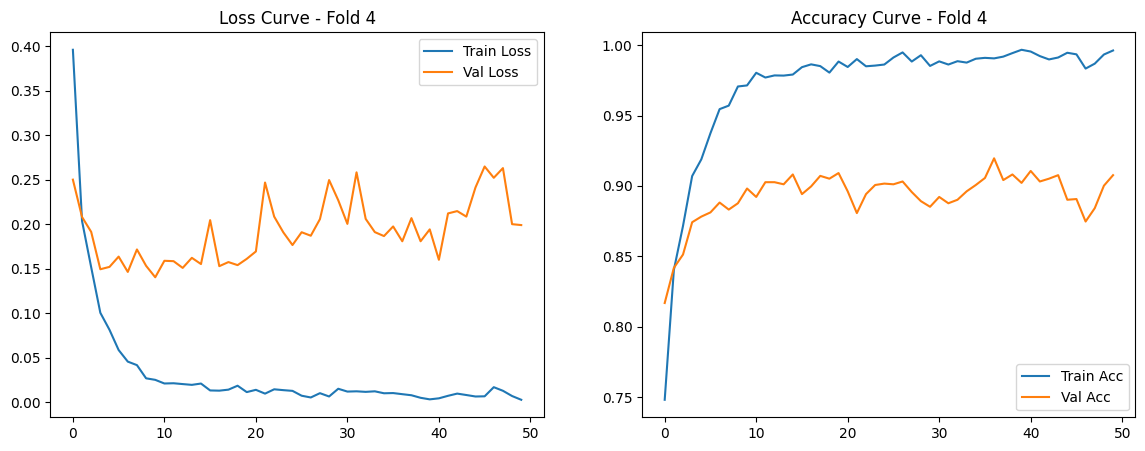

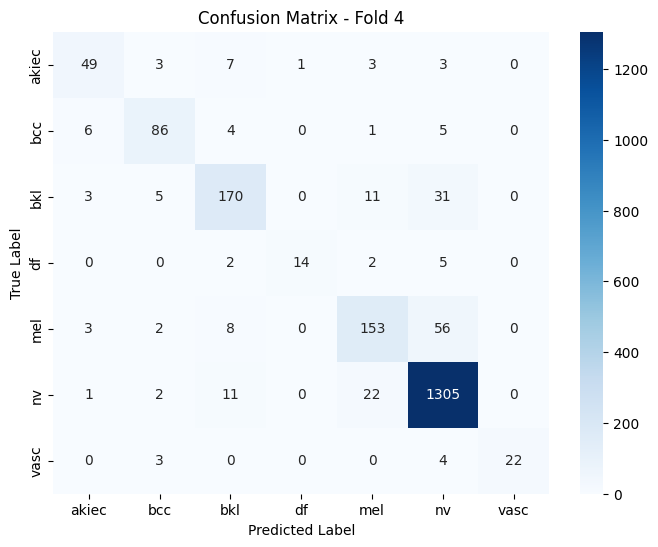

Semua log dan grafik untuk Fold 4 berhasil disimpan di folder: results_exp4

---> Memulai Fold 5 <---
Epoch 1/50 - Train Loss: 0.4060 Acc: 0.7473 | Val Loss: 0.2424 Acc: 0.8258 - 2 menit 10 detik
Epoch 2/50 - Train Loss: 0.2087 Acc: 0.8387 | Val Loss: 0.1781 Acc: 0.8567 - 2 menit 10 detik
Epoch 3/50 - Train Loss: 0.1586 Acc: 0.8674 | Val Loss: 0.1846 Acc: 0.8582 - 2 menit 10 detik
Epoch 4/50 - Train Loss: 0.1071 Acc: 0.9023 | Val Loss: 0.1499 Acc: 0.8747 - 2 menit 10 detik
Epoch 5/50 - Train Loss: 0.0857 Acc: 0.9174 | Val Loss: 0.1346 Acc: 0.8867 - 2 menit 10 detik
Epoch 6/50 - Train Loss: 0.0637 Acc: 0.9378 | Val Loss: 0.1599 Acc: 0.8757 - 2 menit 10 detik
Epoch 7/50 - Train Loss: 0.0466 Acc: 0.9519 | Val Loss: 0.1414 Acc: 0.8897 - 2 menit 10 detik
Epoch 8/50 - Train Loss: 0.0404 Acc: 0.9579 | Val Loss: 0.1398 Acc: 0.8987 - 2 menit 10 detik
Epoch 9/50 - Train Loss: 0.0277 Acc: 0.9707 | Val Loss: 0.1420 Acc: 0.8997 - 2 menit 10 detik
Epoch 10/50 - Train Loss: 0.0318 Acc: 0.9670 | Val L

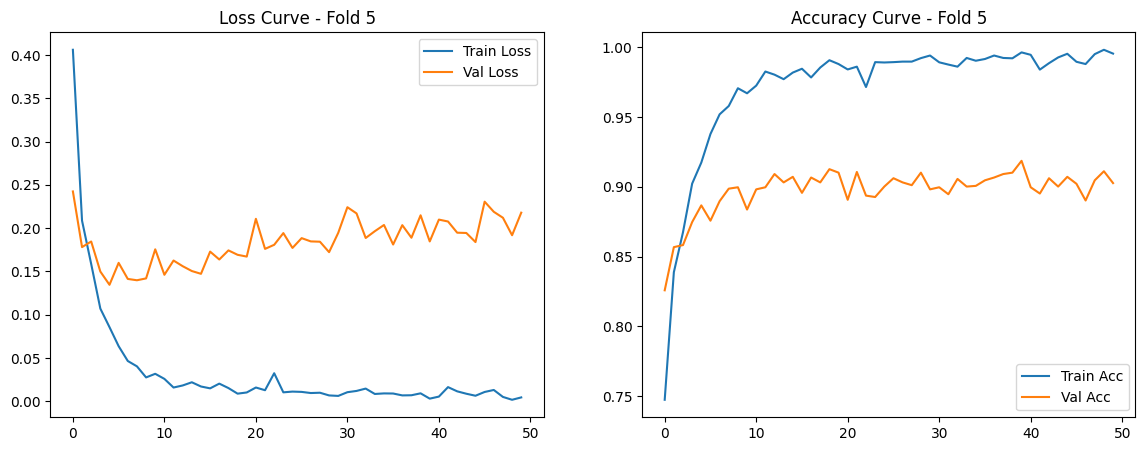

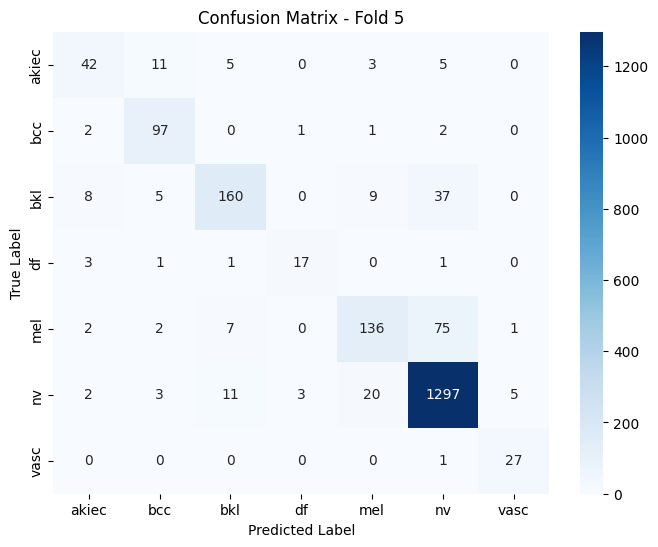

Semua log dan grafik untuk Fold 5 berhasil disimpan di folder: results_exp4

ALHAMDULILLAH, EKSPERIMEN 4 SELESAI TOTAL!
Semua grafik, metric, dan file .pth telah diamankan.


In [8]:
# CELL 7: MASTER EXECUTION LOOP (RUN EXPERIMENT 1)
import torch.optim as optim

# Hyperparameters
BATCH_SIZE = 64
NUM_EPOCHS = 50
LEARNING_RATE = 1e-4

print(f"Mulai Eksperimen 4: ConvNeXt + CBAM + Focal Loss")
print(f"Menyimpan di folder: {SAVE_DIR}\n" + "="*50)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n---> Memulai Fold {fold} <---")
    
    # Bagi dataframe berdasarkan index fold
    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]
    
    # Buat Dataset dan DataLoader
    train_dataset = HAM10000Dataset(train_df, transform=train_transform)
    val_dataset = HAM10000Dataset(val_df, transform=val_transform)
    
    # Gunakan num_workers=4 atau 8 jika CPU Xeon Anda mendukung untuk mempercepat I/O
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Inisialisasi Ulang Model dan Optimizer untuk setiap Fold
    model = ConvNeXt_CA_Attention(num_classes=7).to(device)
    criterion = FocalLoss(gamma=2) # Mengatasi Imbalance
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # Mulai Training
    history, t_time, max_mem = train_model(
        fold=fold, 
        model=model, 
        train_loader=train_loader, 
        val_loader=val_loader, 
        criterion=criterion, 
        optimizer=optimizer, 
        num_epochs=NUM_EPOCHS
    )
    
    # Mulai Evaluasi & Plotting
    evaluate_and_plot(
        fold=fold, 
        model=model, 
        val_loader=val_loader, 
        history=history, 
        training_time=t_time, 
        max_memory=max_mem, 
        class_names=class_names
    )
    
print("\n" + "="*50)
print("ALHAMDULILLAH, EKSPERIMEN 4 SELESAI TOTAL!")
print("Semua grafik, metric, dan file .pth telah diamankan.")

In [9]:
# CELL 8: SUMMARY CALCULATOR (MEAN & STD) - FIXED VERSION
import os
import pandas as pd
import glob

# Pastikan path folder benar sesuai hasil running tadi
class_names = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
results_path = "results_exp4"
csv_files = glob.glob(os.path.join(results_path, "exp4_fold*_classification_report.csv"))

if len(csv_files) < 5:
    print(f"Peringatan: Baru ditemukan {len(csv_files)} file CSV. Pastikan 5 fold sudah selesai running semua.")
else:
    all_reports = []
    
    for file in csv_files:
        # Perbaikan: index_col=0 digunakan agar kolom pertama (nama kelas) jadi index
        df_fold = pd.read_csv(file, index_col=0) 
        all_reports.append(df_fold)
    
    # Gabungkan semua fold
    full_concat = pd.concat(all_reports)
    
    # Hitung rata-rata (Mean) dan Standar Deviasi (Std)
    mean_report = full_concat.groupby(full_concat.index).mean()
    std_report = full_concat.groupby(full_concat.index).std()

    # Mengambil metrik utama (Accuracy dan Macro F1)
    # Note: Di report sklearn, accuracy biasanya ada di baris 'accuracy' kolom 'precision'
    mean_accuracy = mean_report.loc['accuracy', 'precision']
    mean_macro_f1 = mean_report.loc['macro avg', 'f1-score']
    
    std_accuracy = std_report.loc['accuracy', 'precision']
    std_macro_f1 = std_report.loc['macro avg', 'f1-score']
    
    print("="*50)
    print("   HASIL AKHIR EKSPERIMEN 2 (STATISTIK 5-FOLD)")
    print("="*50)
    print(f"Mean Accuracy : {mean_accuracy:.4f} ± {std_accuracy:.4f}")
    print(f"Mean Macro F1 : {mean_macro_f1:.4f} ± {std_macro_f1:.4f}")
    print("-" * 50)
    
    # Tampilkan tabel lengkap rata-rata per kelas agar bisa langsung di-copy ke Paper
    print("\nLaporan Lengkap (Mean Performance per Class):")
    target_rows = class_names + ['macro avg', 'weighted avg']
    summary_table = mean_report.loc[target_rows, ['precision', 'recall', 'f1-score']]
    
    # Menampilkan tabel
    from IPython.display import display
    display(summary_table)
    
    # Simpan hasil akhir ke CSV untuk arsip
    summary_table.to_csv(os.path.join(results_path, "EXP4_FINAL_SUMMARY_STATISTICS.csv"))
    print(f"\n[INFO] Laporan final telah disimpan di: {results_path}/EXP2_FINAL_SUMMARY_STATISTICS.csv")

   HASIL AKHIR EKSPERIMEN 2 (STATISTIK 5-FOLD)
Mean Accuracy : 0.8944 ± 0.0101
Mean Macro F1 : 0.8190 ± 0.0213
--------------------------------------------------

Laporan Lengkap (Mean Performance per Class):


,precision,recall,f1-score
akiec,0.752079,0.752681,0.748684
bcc,0.848921,0.857948,0.852060
bkl,0.844960,0.772482,0.805596
df,0.868235,0.686957,0.758310
mel,0.792262,0.670226,0.724162
nv,0.926959,0.964504,0.945295
vasc,0.899771,0.909113,0.898805
macro avg,0.847598,0.801987,0.818987
weighted avg,0.892212,0.894358,0.891370



[INFO] Laporan final telah disimpan di: results_exp4/EXP2_FINAL_SUMMARY_STATISTICS.csv
